In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [63]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [64]:
df.shape

(1460, 81)

In [65]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Number of numerical columns: 38
Number of categorical columns: 43

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

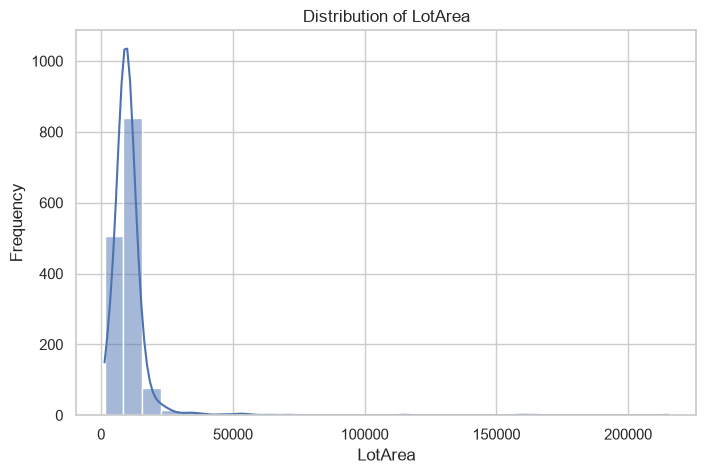

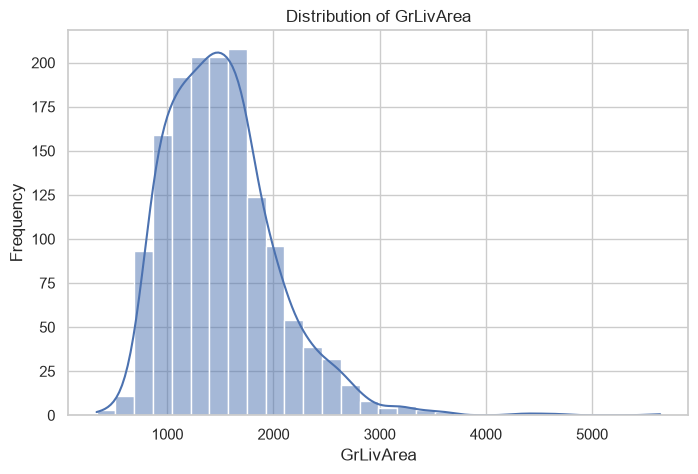

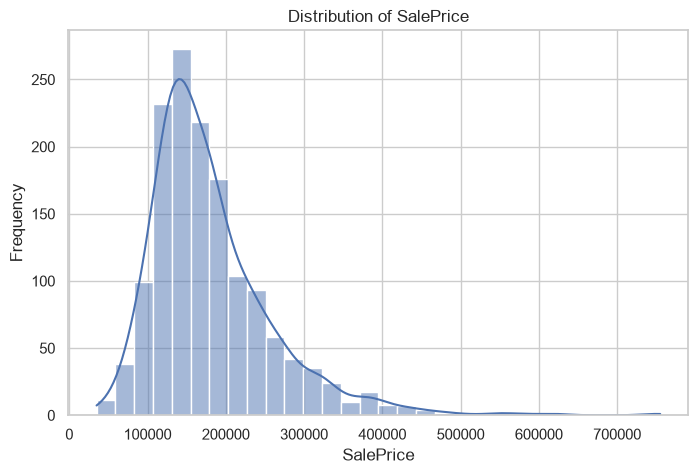

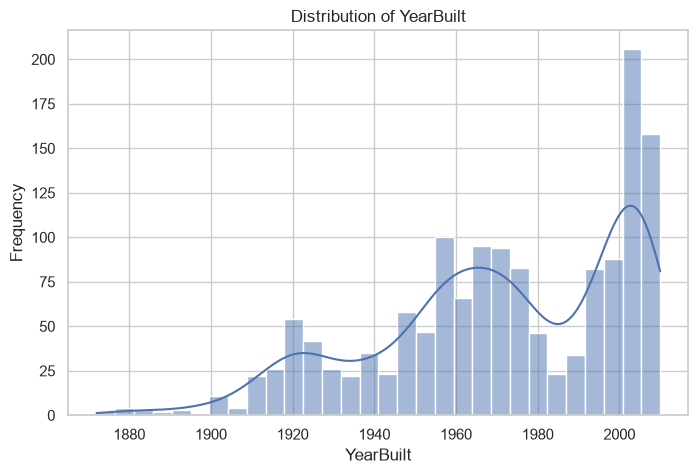

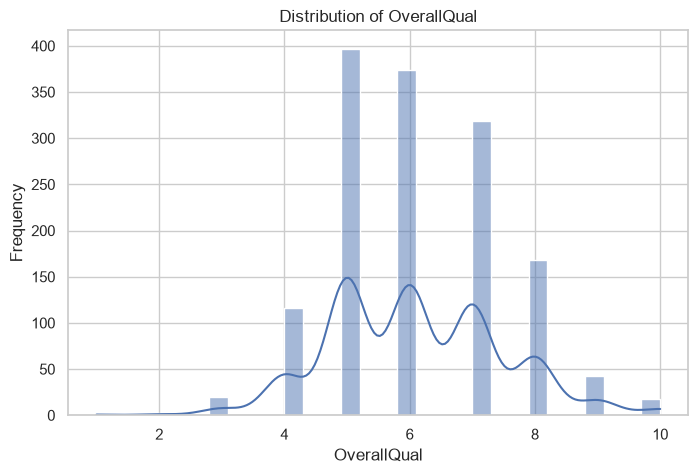

In [67]:
features = [
    "LotArea",
    "GrLivArea",
    "SalePrice",
    "YearBuilt",
    "OverallQual"
]

for feature in features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        df[feature],
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [68]:
for feature in features:
    skewness = df[feature].skew()
    print(f"{feature}: {skewness:.3f}")

LotArea: 12.208
GrLivArea: 1.367
SalePrice: 1.883
YearBuilt: -0.613
OverallQual: 0.217


### Distribution Interpretation

- `LotArea`, `GrLivArea`, and `SalePrice` are positively skewed, with long right tails caused by a small number of very large homes or expensive sales.
- `YearBuilt` is mildly negatively skewed because many homes were built in more recent years.
- `OverallQual` is approximately symmetric compared with the other features, although it is discrete rather than normally distributed.

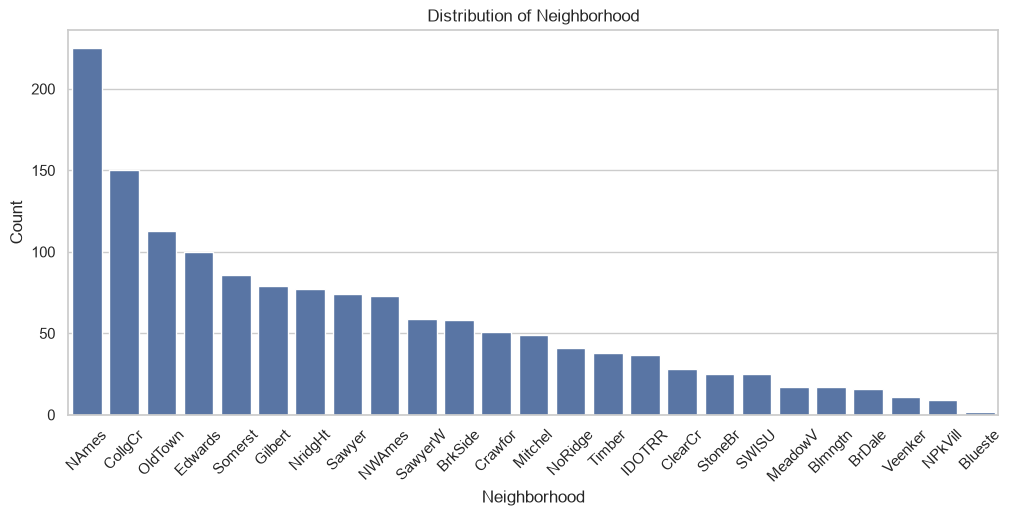

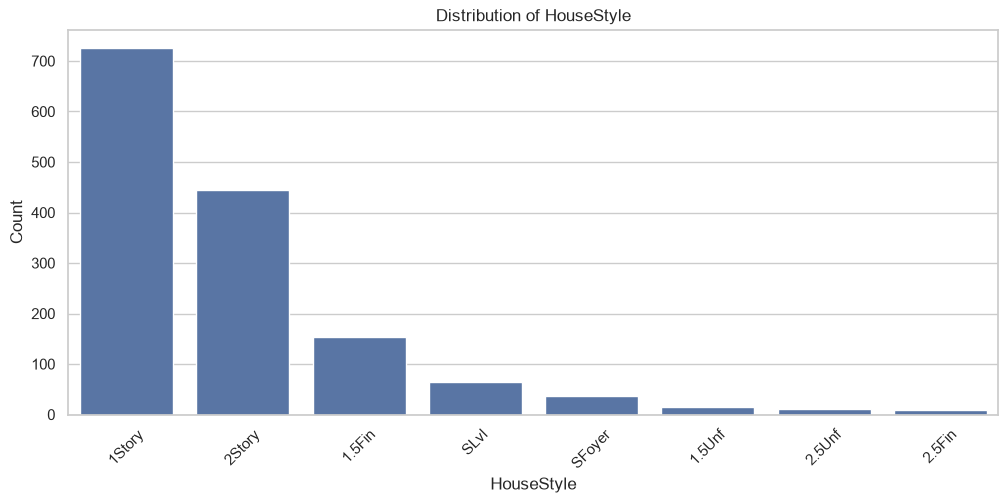

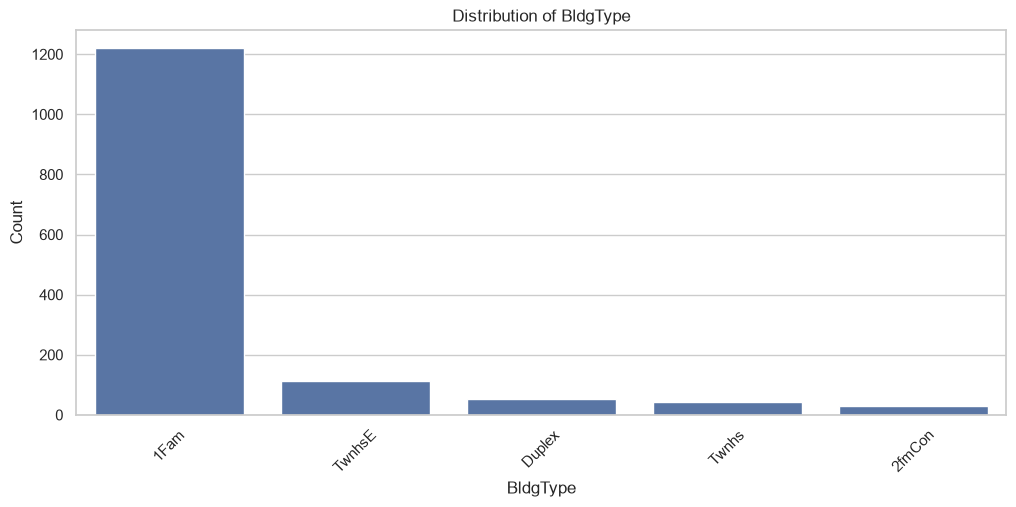

In [69]:
categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "BldgType"
]

for feature in categorical_features:
    
    plt.figure(figsize=(12, 5))
    
    order = df[feature].value_counts().index
    
    sns.countplot(
        data=df,
        x=feature,
        order=order
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    plt.show()

In [70]:
for feature in categorical_features:
    
    print("\n", "=" * 50)
    print(feature)
    print("=" * 50)
    
    print(df[feature].value_counts())


Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

HouseStyle
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

BldgType
BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64


In [71]:
for feature in categorical_features:
    
    counts = df[feature].value_counts()
    
    print(f"\n{feature}")
    print("Most common:")
    print(counts.head(3))
    
    print("\nRarest:")
    print(counts.tail(3))


Neighborhood
Most common:
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Name: count, dtype: int64

Rarest:
Neighborhood
Veenker    11
NPkVill     9
Blueste     2
Name: count, dtype: int64

HouseStyle
Most common:
HouseStyle
1Story    726
2Story    445
1.5Fin    154
Name: count, dtype: int64

Rarest:
HouseStyle
1.5Unf    14
2.5Unf    11
2.5Fin     8
Name: count, dtype: int64

BldgType
Most common:
BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Name: count, dtype: int64

Rarest:
BldgType
Duplex    52
Twnhs     43
2fmCon    31
Name: count, dtype: int64


In [72]:
category_counts = []

for column in categorical_columns:
    
    counts = df[column].value_counts(dropna=False)
    
    for category, count in counts.items():
        
        category_counts.append({
            "Feature": column,
            "Category": category,
            "Count": count
        })

category_counts_df = pd.DataFrame(category_counts)

top_10_categories = category_counts_df.sort_values(
    by="Count",
    ascending=False
).head(10)

print(top_10_categories)

         Feature Category  Count
18     Utilities   AllPub   1459
5         Street     Pave   1454
238       PoolQC      NaN   1453
62    Condition2     Norm   1445
89      RoofMatl  CompShg   1434
176      Heating     GasA   1428
247  MiscFeature      NaN   1406
25     LandSlope      Gtl   1382
7          Alley      NaN   1369
187   CentralAir        Y   1365


In [73]:
for feature in categorical_features:
    
    counts = df[feature].value_counts(normalize=True)
    
    print(f"\n{feature}")
    print((counts.head(5) * 100).round(2))


Neighborhood
Neighborhood
NAmes      15.41
CollgCr    10.27
OldTown     7.74
Edwards     6.85
Somerst     5.89
Name: proportion, dtype: float64

HouseStyle
HouseStyle
1Story    49.73
2Story    30.48
1.5Fin    10.55
SLvl       4.45
SFoyer     2.53
Name: proportion, dtype: float64

BldgType
BldgType
1Fam      83.56
TwnhsE     7.81
Duplex     3.56
Twnhs      2.95
2fmCon     2.12
Name: proportion, dtype: float64


### Category Imbalance

`NAmes` is the most frequent neighborhood, while `Blueste` is rare. `1Story` dominates `HouseStyle`, and `1Fam` strongly dominates `BldgType`. These categories are imbalanced, so their frequencies should be considered when interpreting plots or training models.

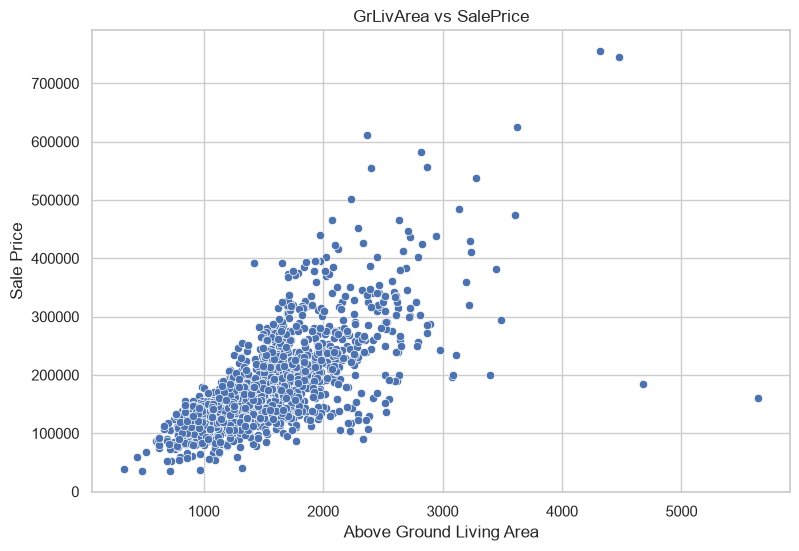

In [74]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

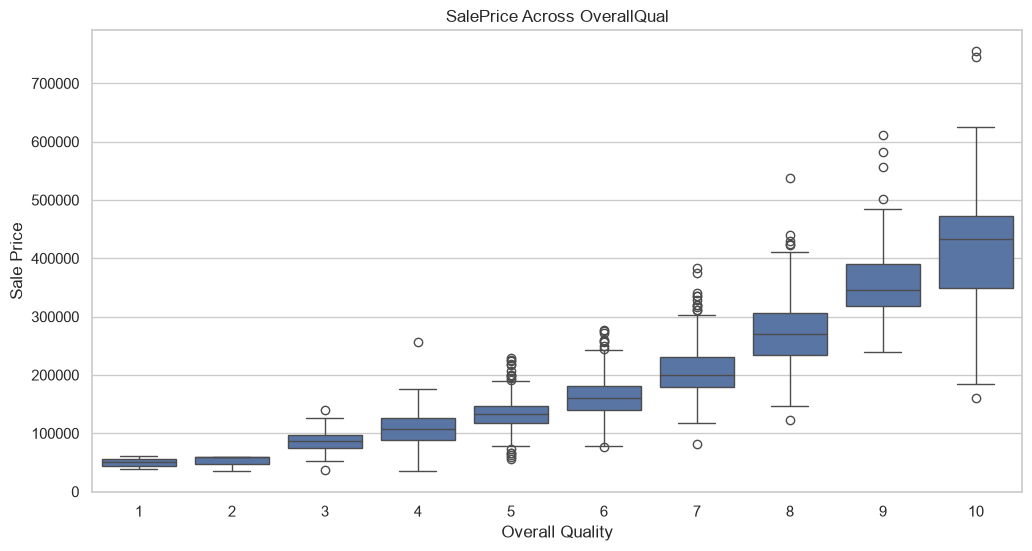

In [75]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("SalePrice Across OverallQual")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

In [76]:
correlation = df.corr(
    numeric_only=True
)

saleprice_corr = correlation["SalePrice"].sort_values(
    ascending=False
)

print(saleprice_corr.head(11))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [77]:
top_features = saleprice_corr.index[1:11]

print("Top 10 features correlated with SalePrice:")
print(top_features)

Top 10 features correlated with SalePrice:
Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='str')


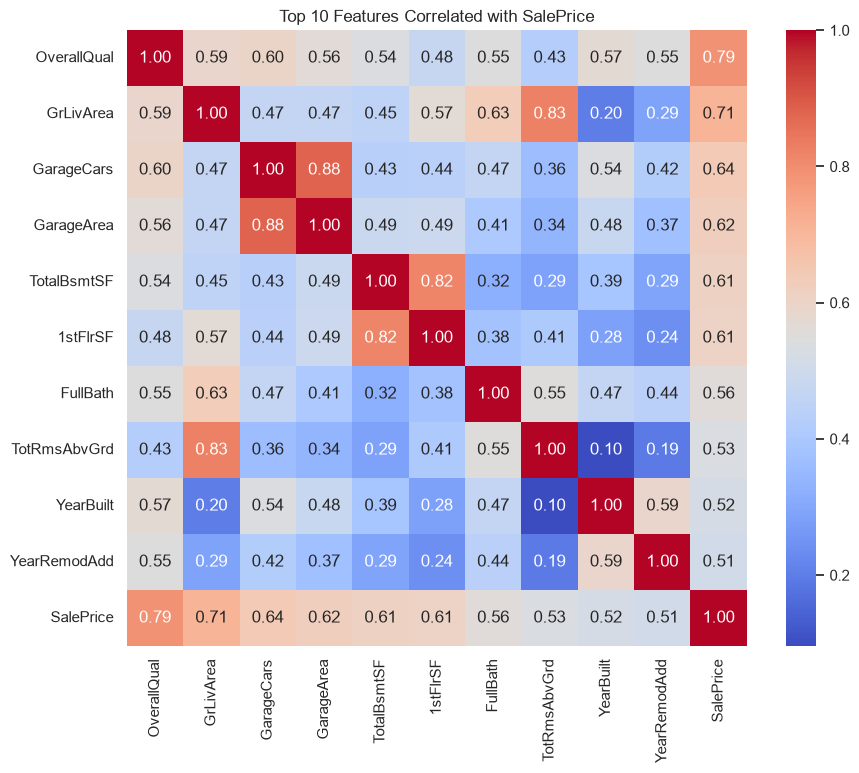

In [78]:
heatmap_features = list(top_features) + ["SalePrice"]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top 10 Features Correlated with SalePrice")

plt.show()

In [79]:
neighborhoods = ["NAmes", "NridgHt"]

comparison = df[
    df["Neighborhood"].isin(neighborhoods)
]

summary = comparison.groupby("Neighborhood")["SalePrice"].agg(
    ["mean", "median", "count"]
)

print(summary)

neighborhood_a = comparison.loc[
    comparison["Neighborhood"] == neighborhoods[0],
    "SalePrice"
]
neighborhood_b = comparison.loc[
    comparison["Neighborhood"] == neighborhoods[1],
    "SalePrice"
]

neighborhood_t_stat, neighborhood_p_value = ttest_ind(
    neighborhood_a,
    neighborhood_b,
    equal_var=False
)

print("Welch t-test statistic:", neighborhood_t_stat)
print("Welch t-test p-value:", neighborhood_p_value)

if neighborhood_p_value < 0.05:
    print("Conclusion: the average SalePrice difference is statistically significant.")
else:
    print("Conclusion: the average SalePrice difference is not statistically significant.")

                       mean    median  count
Neighborhood                                
NAmes         145847.080000  140000.0    225
NridgHt       316270.623377  315000.0     77
Welch t-test statistic: -15.210856147423172
Welch t-test p-value: 1.2850121017015183e-25
Conclusion: the average SalePrice difference is statistically significant.


### Neighborhood Test Interpretation

The Welch two-sample t-test compares the mean `SalePrice` values for `NAmes` and `NridgHt` without assuming equal variances. Since the p-value is below 0.05, we reject the null hypothesis and conclude that the two neighborhood means differ significantly.

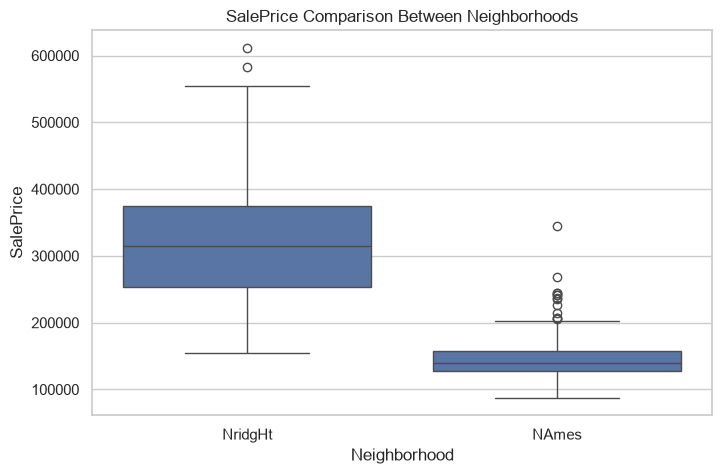

In [80]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=comparison,
    x="Neighborhood",
    y="SalePrice"
)

plt.title("SalePrice Comparison Between Neighborhoods")

plt.show()

In [81]:
df["AgeGroup"] = np.where(
    df["YearBuilt"] >= 2000,
    "Newer",
    "Older"
)

print(
    df.groupby("AgeGroup")["SalePrice"]
    .agg(["mean", "median", "count"])
)

                   mean    median  count
AgeGroup                                
Newer     242439.162371  223750.0    388
Older     158655.364739  144000.0   1072


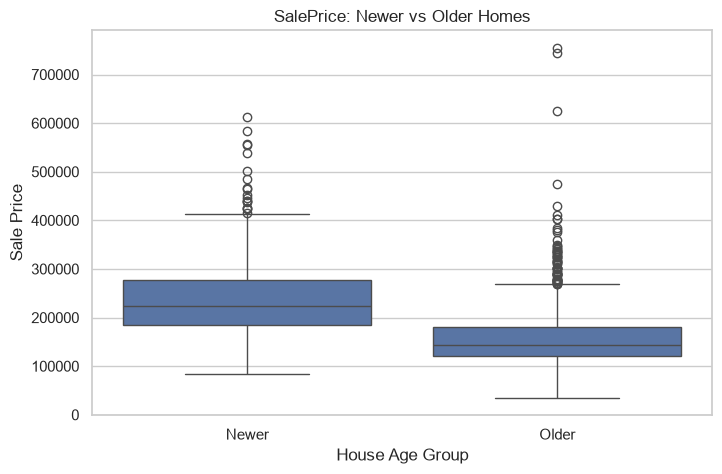

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="AgeGroup",
    y="SalePrice"
)

plt.title("SalePrice: Newer vs Older Homes")
plt.xlabel("House Age Group")
plt.ylabel("Sale Price")

plt.show()

In [83]:
newer_prices = df.loc[
    df["YearBuilt"] >= 2000,
    "SalePrice"
]

older_prices = df.loc[
    df["YearBuilt"] < 2000,
    "SalePrice"
]

In [84]:
t_stat, p_value = ttest_ind(
    newer_prices,
    older_prices,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 18.001293991506017
P-value: 1.0987021443774397e-57


In [85]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference.")
else:
    print("Fail to reject H0: No statistically significant difference.")

Reject H0: There is a statistically significant difference.


In [86]:
missing_values = df.isnull().sum()

missing_values = missing_values.sort_values(
    ascending=False
)

print(missing_values)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
AgeGroup            0
Length: 82, dtype: int64


In [87]:
top_5_missing = missing_values.head(5)

print(top_5_missing)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64


In [88]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

In [89]:
for column in numeric_cols:
    
    if df[column].isnull().sum() > 0:
        
        df[column] = df[column].fillna(
            df[column].median()
        )

In [90]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_cols:
    
    df[column] = df[column].fillna("Missing")

In [91]:
df["LotFrontage"] = df.groupby(
    "Neighborhood"
)["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [92]:
print(
    df["LotFrontage"].isnull().sum()
)

0


In [93]:
df["LotFrontage"] = df["LotFrontage"].fillna(
    df["LotFrontage"].median()
)

In [94]:
remaining_missing = df.isnull().sum()

print(
    remaining_missing[remaining_missing > 0]
)

Series([], dtype: int64)


In [95]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [96]:
Q1_lot = df["LotArea"].quantile(0.25)
Q3_lot = df["LotArea"].quantile(0.75)

IQR_lot = Q3_lot - Q1_lot

lower_lot = Q1_lot - 1.5 * IQR_lot
upper_lot = Q3_lot + 1.5 * IQR_lot

lot_outliers = df[
    (df["LotArea"] < lower_lot) |
    (df["LotArea"] > upper_lot)
]

print("LotArea outliers:", len(lot_outliers))

LotArea outliers: 69


In [97]:
Q1_gr = df["GrLivArea"].quantile(0.25)
Q3_gr = df["GrLivArea"].quantile(0.75)

IQR_gr = Q3_gr - Q1_gr

lower_gr = Q1_gr - 1.5 * IQR_gr
upper_gr = Q3_gr + 1.5 * IQR_gr

grlivarea_outliers = df[
    (df["GrLivArea"] < lower_gr) |
    (df["GrLivArea"] > upper_gr)
]

print("GrLivArea outliers:", len(grlivarea_outliers))

GrLivArea outliers: 31


In [98]:
print("Outlier treatment: capping extreme values with IQR boundaries.")
print("Rows retained:", len(df))

Outlier treatment: capping extreme values with IQR boundaries.
Rows retained: 1460


In [99]:
df["LotArea"] = df["LotArea"].clip(
    lower=lower_lot,
    upper=upper_lot
)

df["GrLivArea"] = df["GrLivArea"].clip(
    lower=lower_gr,
    upper=upper_gr
)

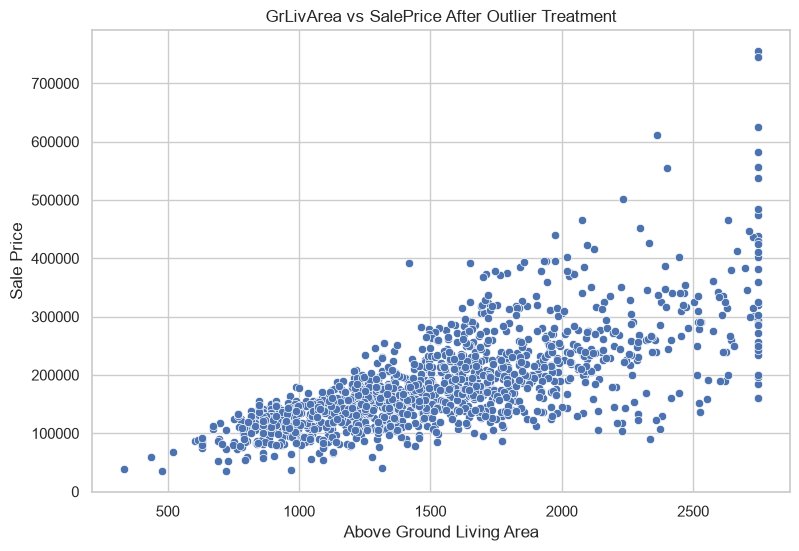

In [100]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLivArea vs SalePrice After Outlier Treatment")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

### Outlier Treatment Interpretation

The IQR rule identifies extreme observations using values below $Q1 - 1.5\times IQR$ or above $Q3 + 1.5\times IQR$. I cap `LotArea` and `GrLivArea` at these bounds instead of deleting rows, because the observations may represent genuine large properties. Capping reduces the influence of extreme values while retaining the full dataset.

In [101]:
numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove target and ID
numeric_features.remove("SalePrice")
numeric_features.remove("Id")

In [102]:
scaler = StandardScaler()

df[numeric_features] = scaler.fit_transform(
    df[numeric_features]
)

In [103]:
print(df[numeric_features].head())

   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0    0.073375    -0.220875 -0.333244     0.651479    -0.517200   1.050994   
1   -0.872563     0.460320 -0.013189    -0.071836     2.179628   0.156734   
2    0.073375    -0.084636  0.446022     0.651479    -0.517200   0.984752   
3    0.309859    -0.447940 -0.027104     0.651479    -0.517200  -1.863632   
4    0.073375     0.641972  1.283733     1.374795    -0.517200   0.951632   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  GarageArea  \
0      0.878668    0.514104    0.575425   -0.288653  ...    0.351000   
1     -0.429577   -0.570750    1.171992   -0.288653  ...   -0.060731   
2      0.830215    0.325915    0.092907   -0.288653  ...    0.631726   
3     -0.720298   -0.570750   -0.499274   -0.288653  ...    0.790804   
4      0.733308    1.366489    0.463568   -0.288653  ...    1.698485   

   WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  \
0   -0.752176     0.21650

In [104]:
df_processed = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

In [105]:
print("Processed shape:", df_processed.shape)

Processed shape: (1460, 307)


In [106]:
df_processed.to_csv(
    "house_prices_clean.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [107]:
import os

print(
    "File exists:",
    os.path.exists("house_prices_clean.csv")
)

File exists: True


In [108]:
print("Rows:", df_processed.shape[0])
print("Columns:", df_processed.shape[1])

print(
    "Total missing values:",
    df_processed.isnull().sum().sum()
)

Rows: 1460
Columns: 307
Total missing values: 0


In [109]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [110]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [111]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [112]:
iris_df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

iris_df["Species"] = [
    iris.target_names[i]
    for i in y
]

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [114]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [115]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]

results = []

for k in k_values:
    
    for metric in ["euclidean", "manhattan"]:
        
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )
        
        knn.fit(
            X_train_scaled,
            y_train
        )
        
        y_pred = knn.predict(
            X_test_scaled
        )
        
        accuracy = accuracy_score(
            y_test,
            y_pred
        )
        
        precision = precision_score(
            y_test,
            y_pred,
            average="weighted"
        )
        
        recall = recall_score(
            y_test,
            y_pred,
            average="weighted"
        )
        
        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
        
        results.append({
            "K": k,
            "Distance": metric,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

In [116]:
results_df = pd.DataFrame(results)

results_df

,K,Distance,Accuracy,Precision,Recall,F1
0,1,euclidean,0.966667,0.969697,0.966667,0.966583
1,1,manhattan,0.966667,0.969697,0.966667,0.966583
2,3,euclidean,0.933333,0.944444,0.933333,0.932660
3,3,manhattan,0.966667,0.969697,0.966667,0.966583
4,5,euclidean,0.933333,0.944444,0.933333,0.932660
5,5,manhattan,0.933333,0.944444,0.933333,0.932660
6,7,euclidean,0.966667,0.969697,0.966667,0.966583
7,7,manhattan,0.966667,0.969697,0.966667,0.966583
8,9,euclidean,0.966667,0.969697,0.966667,0.966583
9,9,manhattan,0.933333,0.933333,0.933333,0.933333


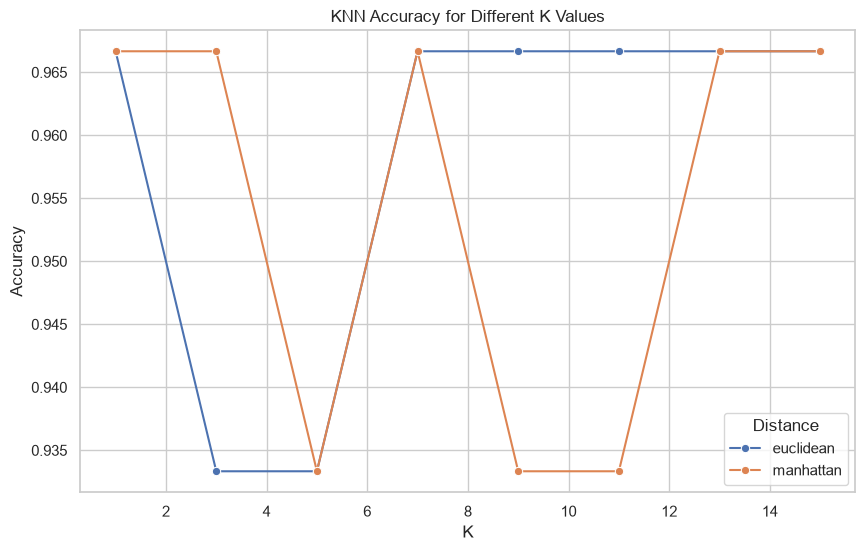

In [117]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="K",
    y="Accuracy",
    hue="Distance",
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K")
plt.ylabel("Accuracy")

plt.show()

In [118]:
best_result = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best result:")
print(best_result)

Best result:
K                    1
Distance     euclidean
Accuracy      0.966667
Precision     0.969697
Recall        0.966667
F1            0.966583
Name: 0, dtype: object


In [119]:
best_k = int(best_result["K"])
best_metric = best_result["Distance"]

final_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

final_knn.fit(
    X_train_scaled,
    y_train
)

y_pred = final_knn.predict(
    X_test_scaled
)

In [120]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [121]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



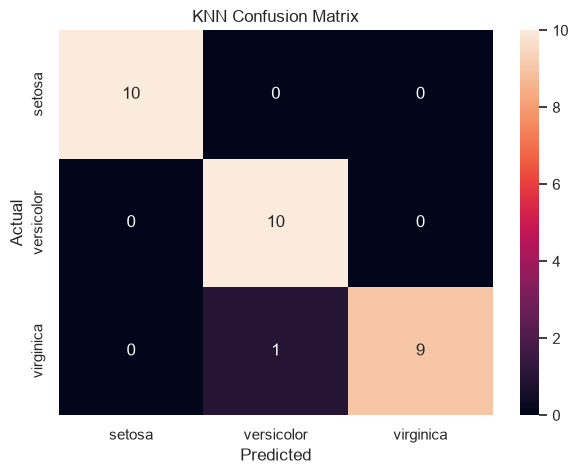

In [122]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()